# 라이브러리

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 데이터 확인

In [3]:
df = pd.read_csv(
    "../data/raw/household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

# Date + Time을 합쳐서 datetime 컬럼 생성
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

# 원래 Date, Time 컬럼은 제거 (선택 사항)
df = df.drop(columns=["Date", "Time"])

print(df.shape)
df.head()

(2075259, 8)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


## 결측치 확인

In [4]:
df.isnull().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
datetime                     0
dtype: int64

### 해석

+ 1440은 하루가 통째로 빈 날(24시간 x 60분)
    + 2007-04-29, 2009-06-14, 2010-01-13, 2010-08-18~21, 2010-09-26~27
    + 랜덤하게 여기저기 흩어진 결측이 아니라 연속된 블록 단위로 통째로 빠짐

+ 연속된 날짜들이 뭉쳐 있는 경우
    + 2010-08-18, 19, 20, 21, 22 는 5일 연속으로 결측
    + 2010-09-25, 26, 27, 28 은 4일 연속 결측

In [5]:
missing_mask = df["Global_active_power"].isnull()
df[missing_mask]["datetime"].dt.date.value_counts().head(20)

datetime
2007-04-29    1440
2009-06-14    1440
2010-01-13    1440
2010-08-18    1440
2010-08-19    1440
2010-08-20    1440
2010-08-21    1440
2010-09-26    1440
2010-09-27    1440
2007-04-28    1419
2009-06-13    1410
2010-08-22    1288
2010-03-20    1208
2010-09-25    1204
2010-09-28    1153
2010-01-14    1142
2009-08-13     891
2007-04-30     864
2010-03-21     819
2010-01-12     547
Name: count, dtype: int64

### 해석

+ 짧은 결측(1~3분)
    + 54개
    + 순간적인 통신 끊김/노이즈
    + 선형보간

+ 긴 결측(수 시간 ~ 5일)
    + 소수(약 17개)
    + 스마트미터 고장/점검 예상
    + 구간을 제외하거나 별도 플래그 처리

In [6]:
# 결측 블록 길이 분포 확인 (연속된 결측이 몇 분/몇 시간짜리가 몇 개인지)
df["is_missing"] = df["Global_active_power"].isnull()
df["missing_group"] = (df["is_missing"] != df["is_missing"].shift()).cumsum()
missing_blocks = df[df["is_missing"]].groupby("missing_group").size()

print(missing_blocks.describe())
print(missing_blocks.value_counts().head(10))

count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
dtype: float64
1       38
2       14
3        2
3723     1
33       1
83       1
47       1
21       1
43       1
6        1
Name: count, dtype: int64


In [7]:
# 긴 결측 블록만 따로 확인 (예: 60분 이상)
long_missing = missing_blocks[missing_blocks >= 60].sort_values(ascending=False)
print(long_missing)

missing_group
138    7226
140    5237
14     3723
100    3305
118    3129
126    2027
104     891
32       83
78       70
dtype: int64


### 결측치 결론

+ missing_group(긴 결측 블록)의 합계 : 25,691분
+ 전체 결측치 : 25,979개


+ 긴 결측 블록 9개가 전체 결측의 약 98.9% 차지
+ 나머지 62개 블록(1~3분)은 겨우 1.1%

+ 9번의 대형 장애 사건 + 그 외 작은 순간 끊김

In [8]:
# 각 missing_group의 시작/종료 시각 확인
long_groups = [138, 140, 14, 100, 118, 126, 104, 32, 78]

for g in long_groups:
    block = df[df["missing_group"] == g]
    start = block["datetime"].min()
    end = block["datetime"].max()
    duration = block.shape[0]
    print(f"그룹 {g}: {start} ~ {end} ({duration}분, 약 {duration/60/24:.1f}일)")

그룹 138: 2010-08-17 21:02:00 ~ 2010-08-22 21:27:00 (7226분, 약 5.0일)
그룹 140: 2010-09-25 03:56:00 ~ 2010-09-28 19:12:00 (5237분, 약 3.6일)
그룹 14: 2007-04-28 00:21:00 ~ 2007-04-30 14:23:00 (3723분, 약 2.6일)
그룹 100: 2009-06-13 00:30:00 ~ 2009-06-15 07:34:00 (3305분, 약 2.3일)
그룹 118: 2010-01-12 14:53:00 ~ 2010-01-14 19:01:00 (3129분, 약 2.2일)
그룹 126: 2010-03-20 03:52:00 ~ 2010-03-21 13:38:00 (2027분, 약 1.4일)
그룹 104: 2009-08-13 05:00:00 ~ 2009-08-13 19:50:00 (891분, 약 0.6일)
그룹 32: 2007-07-15 16:49:00 ~ 2007-07-15 18:11:00 (83분, 약 0.1일)
그룹 78: 2008-12-10 10:48:00 ~ 2008-12-10 11:57:00 (70분, 약 0.0일)


## 짧은 결측치 처리
+ 선형보간

In [9]:
# 결측 블록 크기를 각 행에 표시
group_sizes = df.groupby("missing_group").size()
df["missing_block_size"] = df["missing_group"].map(group_sizes)

In [10]:
# 필요한 숫자 컬럼 목록 정의
numeric_cols = [
    "Global_active_power", "Global_reactive_power", "Voltage",
    "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]

In [11]:
# 짧은 결측 / 긴 결측 구분 플래그 만들기
df["short_missing"] = df["is_missing"] & (df["missing_block_size"] <= 5)
df["long_missing"] = df["is_missing"] & (df["missing_block_size"] > 5)

In [12]:
# 짧은 결측만 선형보간으로 채우는 함수
def preprocess_missing(df, numeric_cols):
    df = df.copy()
    for col in numeric_cols:
        mask = df["short_missing"]
        df.loc[mask, col] = df[col].interpolate(method="linear")[mask]
    return df

In [13]:
# 함수 호출 후 반환값을 df에 재할당
df = preprocess_missing(df, numeric_cols)

In [14]:
print(df[df["short_missing"]][numeric_cols].isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


## 긴 결측 처리
+ 긴 결측 구간을 삭제하지 않고 그대로 NaN으로 남긴 다음 구간 플래그만 유지

In [15]:
# 긴 결측 구간(long_missing)은 삭제하지 않고 NaN 그대로 유지
# → 시계열 인덱스(datetime) 연속성을 보존하고, 이후 분석/모델링 단계에서
#    필요에 따라 구간을 제외하거나 포함할 수 있도록 플래그만 남겨둠

# 최종 결측치 현황 확인
print("전체 결측치 개수:", df[numeric_cols].isnull().sum().sum())
print()
print("short_missing (처리 완료, 0이어야 정상):")
print(df[df["short_missing"]][numeric_cols].isnull().sum())
print()
print("long_missing (의도적으로 남겨둔 결측):")
print(df[df["long_missing"]][numeric_cols].isnull().sum())

전체 결측치 개수: 181321

short_missing (처리 완료, 0이어야 정상):
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

long_missing (의도적으로 남겨둔 결측):
Global_active_power      25903
Global_reactive_power    25903
Voltage                  25903
Global_intensity         25903
Sub_metering_1           25903
Sub_metering_2           25903
Sub_metering_3           25903
dtype: int64


In [16]:
# 긴 결측 구간이 포함된 날짜 목록 (나중에 일별 집계 시 참고용)
long_missing_dates = df[df["long_missing"]]["datetime"].dt.date.unique()
print("긴 결측이 발생한 날짜:")
for d in sorted(long_missing_dates):
    print(d)

긴 결측이 발생한 날짜:
2007-04-28
2007-04-29
2007-04-30
2007-06-09
2007-07-15
2007-08-01
2008-10-25
2008-11-10
2008-12-10
2009-02-01
2009-02-17
2009-06-13
2009-06-14
2009-06-15
2009-08-13
2010-01-12
2010-01-13
2010-01-14
2010-03-20
2010-03-21
2010-08-17
2010-08-18
2010-08-19
2010-08-20
2010-08-21
2010-08-22
2010-09-25
2010-09-26
2010-09-27
2010-09-28


In [17]:
# 전처리 완료된 데이터 저장 (다음 단계 노트북에서 바로 불러다 쓰기 위함)
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/power_consumption_cleaned.csv", index=False)

print("저장 완료:", df.shape)

저장 완료: (2075259, 13)


# 정상 패턴 EDA

In [18]:
# 기본 통계량 확인
print(df[numeric_cols].describe())

       Global_active_power  Global_reactive_power       Voltage  \
count         2.049356e+06           2.049356e+06  2.049356e+06   
mean          1.091645e+00           1.237169e-01  2.408398e+02   
std           1.057324e+00           1.127237e-01  3.239989e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1.528000e+00           1.940000e-01  2.428900e+02   
max           1.112200e+01           1.390000e+00  2.541500e+02   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count      2.049356e+06    2.049356e+06    2.049356e+06    2.049356e+06  
mean       4.627889e+00    1.121981e+00    1.298590e+00    6.458515e+00  
std        4.444523e+00    6.153206e+00    5.822073e+00    8.437165e+00  
min        2.000000e-01    0.000000e+00    0.000000e+00    0.000000e+00  
25%        1.400000e+00   

#### 통계량 확인 정리

+ 전체 데이터 개수 : 2,049,356개

+ Global_active_power(유효 전력, kW)
    + 평균 : 1.0916kW
    + 표준편차 : 1.0573 (평균과 비슷, 변동성이 큰 데이터)
    + 최솟값 : 0.076
    + 중앙값 : 0.602
    + 최댓값 : 11.122 (일부 시간대에 전력 사용량 급증 존재)


+ Global_reactive_power(무효 전력, kW)
    + 평균 : 0.1237
    + 표준편차 : 0.1127
    + 최솟값 : 0
    + 중앙값 : 0.100
    + 최댓값 : 1.39

+ Voltage(전압, V)
    + 평균 : 240.84V
    + 표준편차 : 3.24V (매우 작음, 비교적 안정적으로 유지)
    + 최솟값 : 223.2V
    + 최댓값 : 254.15V

+ Global_intensity (전류, A)
    + 평균 : 4.63A
    + 표준편차 : 4.44A
    + 최댓값 : 48.4A (평균보다 최댓값이 훨씬 큼, 전류가 급격히 증가하는 구간 존재)

+ Sub_metering_1
    + 평균 : 1.12
    + 중앙값 : 0
    + 75% : 0 (전체 데이터의 75% 이상이 0)
    + 최댓값 : 88 (특정 시간에만 사용되는 전력의 특성)

+ Sub_metering_2
    + 평균 : 1.30
    + 중앙값 : 0
    + 75% : 1
    + 최댓값 : 80
    + 대부분의 값이 0 또는 매우 작은 값
    + 일부 시점에서만 소비량이 크게 증가
    + 희소한 데이터의 특징

+ Sub_metering_3
    + 평균 : 6.46
    + 중앙값 : 1
    + 75% : 17
    + 최댓값 : 31
    + 다른 Sub_metering 변수보다 평균이 가장 높음
    + 지속적으로 전력을 사용하는 장치의 소비량일 가능성 높음

In [19]:
# 2. 시간 단위로 리샘플링 (1분 단위는 너무 세밀해서 패턴이 잘 안 보임)
df_resampled = df.set_index("datetime")[numeric_cols].resample("1h").mean()
print(df_resampled.shape)
df_resampled.head()

(34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


#### 시간 단위 패턴

+ 1시간 간격
+ 값 : 해당 1시간 동안의 평균값
+ 시작 시점 : 2006-12-06


+ 17시
    + Global_active_power : 4.223kW
    + Voltage : 234.64V
    + Global_intensity : 18.10A
    + Sub_metering_3 : 16.86
    + 평균 소비전력이 매우 높은 수준
    + 많은 전력을 사용한 시간대
    + Sub_metering_1은 0으로 해당 시간에는 사용하지 않음


+ 18시
    + Global_active_power : 3.632
    + Sub_metering_2
    + 17시에 비해 전력 사용량이 감소

In [20]:
# Windows: 맑은 고딕 사용
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

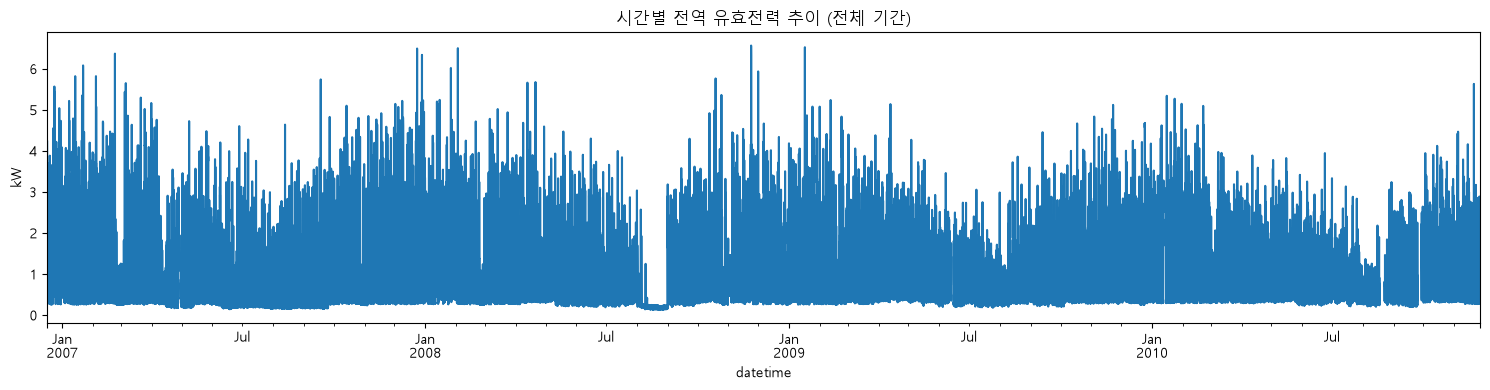

In [21]:
# 전체 기간 전력 사용량 추이 시각화

fig, ax = plt.subplots(figsize=(15, 4))
df_resampled["Global_active_power"].plot(ax=ax)
ax.set_title("시간별 전역 유효전력 추이 (전체 기간)")
ax.set_ylabel("kW")
plt.tight_layout()
plt.show()

#### 전체 기간 추이 확인

+ 2006년 12월 ~ 2010년 11월, 약 4년치 데이터
+ 뚜렷한 계절성 패턴 확인
    + 겨울철(12~2월) 사용량이 전반적으로 높고, 변동폭도 큼
    + 여름철(6~8월) 사용량이 상대적으로 낮고 안정적
    + 난방 관련 전력 사용이 계절 변동의 주요 원인으로 추정
+ 긴 결측 구간(9개 블록)이 시각적으로 끊긴 구간(빈 공백)으로 나타남
+ 산발적으로 튀는 스파이크 구간 존재 → 자연발생 극단값 탐색('[30]' 이후)에서 자세히 확인 예정

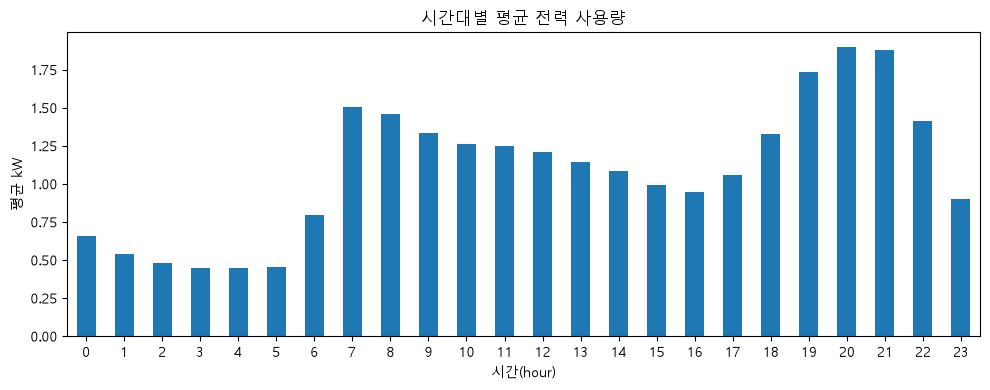

In [22]:
# 하루 패턴 확인 (시간대별 평균 사용량)
df["hour"] = df["datetime"].dt.hour
hourly_pattern = df.groupby("hour")["Global_active_power"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_pattern.plot(kind="bar", ax=ax)
# x축 글씨 가로로 표시
ax.tick_params(axis='x', rotation=0)
ax.set_title("시간대별 평균 전력 사용량")
ax.set_xlabel("시간(hour)")
ax.set_ylabel("평균 kW")
plt.tight_layout()
plt.show()

#### 시간대별 평균 전력 사용량 확인

+ 새벽(0~5시)이 하루 중 가장 낮은 (0.44~0.66kW 수준)
+ 아침 6~7시부터 급격히 상승 (기상 후 활동 시작 추정)
+ 저녁 19~21시가 하루 중 최고 피크 (평균 1.73~1.90kW)
    + 특히 20시가 1.899kW로 최고치
+ 낮 시간대(9~16시)는 완만하게 감소하는 흐름 → 재실 인원이 적은 시간대로 추정

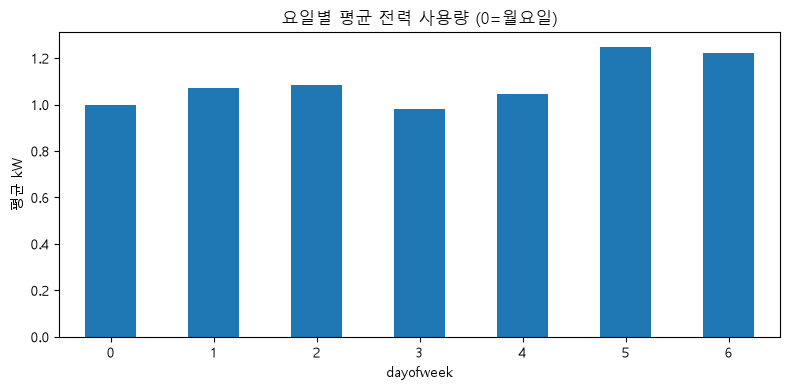

In [23]:
# 요일별 패턴 확인
df["dayofweek"] = df["datetime"].dt.dayofweek  # 0=월, 6=일
daily_pattern = df.groupby("dayofweek")["Global_active_power"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
daily_pattern.plot(kind="bar", ax=ax)
# x축 글씨 가로로 표시
ax.tick_params(axis='x', rotation=0)
ax.set_title("요일별 평균 전력 사용량 (0=월요일)")
ax.set_ylabel("평균 kW")
plt.tight_layout()
plt.show()

#### 요일별 평균 전력 사용량 확인

+ 요일 간 차이가 시간대별 차이만큼 크지는 않음
+ 주말(토·일)이 평일보다 다소 높은 경향
+ 요일 자체보다는 "평일이냐 주말이냐"의 이분법적 구분이 더 유의미해 보임

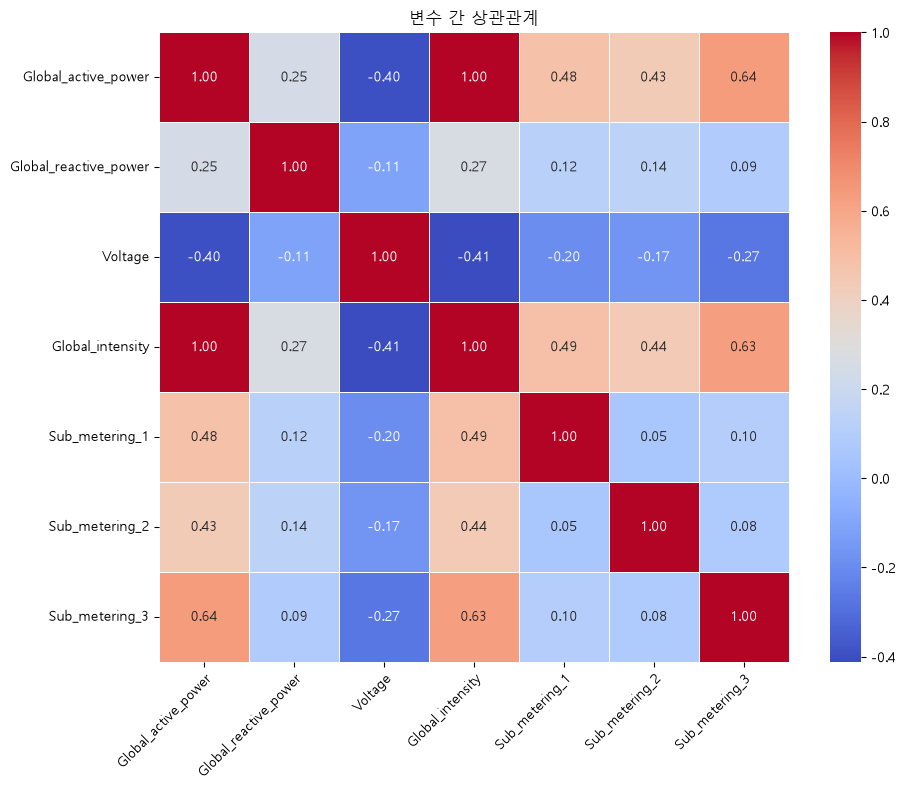

In [24]:
# 변수 간 상관관계 확인
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,      # 셀을 정사각형으로
    linewidths=0.5,   # 셀 경계선
    ax=ax
)

ax.set_title("변수 간 상관관계")

# x축과 y축 레이블 정리
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

#### 변수 간 상관관계 확인

+ Global_active_power ↔ Global_intensity : 매우 강한 양의 상관관계
    + 전력과 전류는 물리적으로 비례 관계이므로 당연한 결과
+ Global_active_power ↔ Sub_metering_3(온수기·에어컨 추정) : 상대적으로 높은 상관관계
    + 전체 사용량 변동에 온수기/에어컨 계열 기기의 기여도가 크다는 것을 시사
+ Voltage는 다른 변수들과 상관관계가 거의 없음 (독립적으로 변동)
    + 전압은 외부 배전 상태에 더 영향을 받는 변수로, 이상탐지 시 "설비/계통 이상" 신호로 따로 볼 가치가 있음
+ Sub_metering_1, 2는 Global_active_power와의 상관관계가 상대적으로 약함
    + 주방·세탁실 기기는 간헐적 사용 특성이 강해 전체 흐름과의 연동성이 낮은 것으로 추정

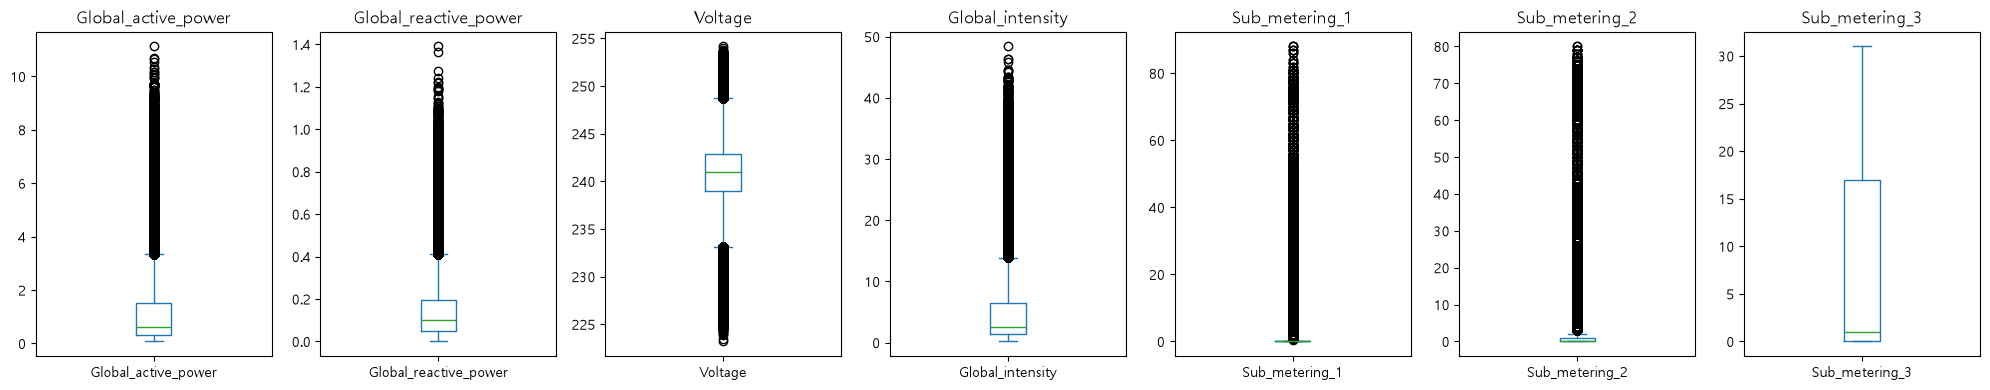

In [25]:
# 극단값(outlier) 대략 확인 - boxplot
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    df[col].plot(kind="box", ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

#### Boxplot 기반 극단값 확인

+ Global_active_power, Global_intensity
    + 박스 위쪽으로 극단값이 많이 분포
    + 사용량 급증 케이스가 다수 존재

+ Voltage
    +극단값이 상대적으로 적고 좁은 범위에 분포 → 안정적인 변수

+ Sub_metering_1, 2, 3
    + 대부분 0 근처에 몰려있고, 사용 시에만 튀는 형태(간헐적 온/오프 특성)

+ 전반적으로 "평소엔 낮게 유지되다가 특정 시점에만 튀는" 패턴이 여러 변수에서 공통적으로 관찰
    + 이상치 주입 시 "급증형" 패턴이 실제 데이터 특성과 잘 맞는 방향임을 시사

In [26]:
# 시간대별 평균 + 표준편차 (변동 범위 파악)
hourly_stats = df.groupby("hour")["Global_active_power"].agg(["mean", "std", "min", "max"])
print(hourly_stats)

          mean       std    min     max
hour                                   
0     0.659434  0.717914  0.078   7.698
1     0.539325  0.585604  0.078  10.290
2     0.480618  0.488526  0.078   6.248
3     0.444866  0.430038  0.078   4.426
4     0.443847  0.425120  0.078   4.796
5     0.453674  0.445886  0.078   6.376
6     0.791631  0.928929  0.078   8.310
7     1.502264  1.081839  0.078   9.486
8     1.461049  0.950002  0.078   8.126
9     1.331643  0.855901  0.078   7.732
10    1.260751  0.906712  0.078   9.078
11    1.245797  1.004152  0.078   8.504
12    1.207076  1.067104  0.078   9.224
13    1.144538  1.048987  0.078   9.590
14    1.082881  1.029232  0.078   8.418
15    0.990815  1.002492  0.078   8.848
16    0.948942  0.955823  0.078   8.446
17    1.055100  1.037659  0.078  11.122
18    1.326465  1.204779  0.078   9.724
19    1.733347  1.350010  0.076  10.670
20    1.899103  1.380542  0.076  10.348
21    1.877786  1.291930  0.076   9.410
22    1.412674  1.096782  0.078   9.272


#### 시간대별 평균 + 표준편차

+ 새벽(0~5시) 가장 낮고 안정적
    + 평균 0.44~0.66kW, 표준편차도 0.43~0.72로 하루 중 가장 작음
+ 6시부터 급격히 상승
    + 5시 평균 0.45kW → 7시 1.50kW로 3배 이상 증가
+ 저녁 19~21시가 하루 중 최대 피크
    + 평균 1.73~1.90kW
    + 20시 최고 1.899kW
+ 표준편차가 평균과 맞먹거나 그 이상인 시간대가 많음
    + 20시 : 평균 1.89 vs 표준편차 1.381
    + 6시 : 평균 0.792 vs 표준편차 0.929
    + 해당 시간대의 "정상 범위" 자체가 매우 넓다는 의미
+ max 값이 시간대마다 들쭉날쭉하게 튐
    + 17시 11.122kW(전체 최댓값), 1시 10.290kW
+ 새벽 시간대(0~5시)는 상대적으로 max도 낮은 편(4.4~7.7kW 수준)


**모델링 시사점**
1. 시간대를 무시한 단일 임계값은 위험함 → 시간대별로 정상 범위를 다르게 설정해야 함
2. 변동성이 큰 시간대(6시, 저녁 피크)는 오탐 위험이 상대적으로 높음
3. 새벽 시간대는 표준편차가 작아 이상탐지에 유리

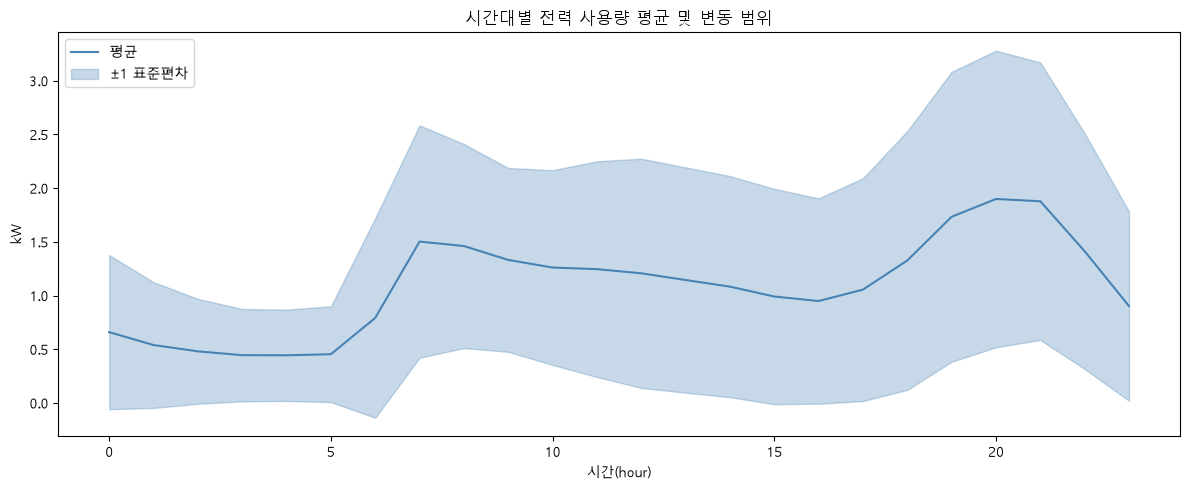

In [27]:
# 시간대별 평균 ± 표준편차 밴드
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_stats.index, hourly_stats["mean"], label="평균", color="steelblue")
ax.fill_between(
    hourly_stats.index,
    hourly_stats["mean"] - hourly_stats["std"],
    hourly_stats["mean"] + hourly_stats["std"],
    alpha=0.3, color="steelblue", label="±1 표준편차"
)
ax.set_title("시간대별 전력 사용량 평균 및 변동 범위")
ax.set_xlabel("시간(hour)")
ax.set_ylabel("kW")
ax.legend()
plt.tight_layout()
plt.show()

#### 시간대별 변동 범위 시각화

+ 저녁 피크 시간대(19~21시)는 평균도 높고 밴드(변동 범위)도 가장 넓음
    + 정상 범위 자체가 넓어 오탐(False Positive) 위험이 큰 구간
+ 새벽 시간대(0~5시)는 평균도 낮고 밴드도 좁음
    + 정상 범위가 좁아 오히려 이상 탐지가 용이한 구간
+ 밴드의 하한선이 대부분 음수로 내려가는 시간대가 많음
    + 실제 값은 0 이상이므로 정규분포 가정이 완벽히 맞진 않음
    + 표준편차 기반 임계값보다는 분포 특성을 반영한 방법이 더 적합할 수 있음

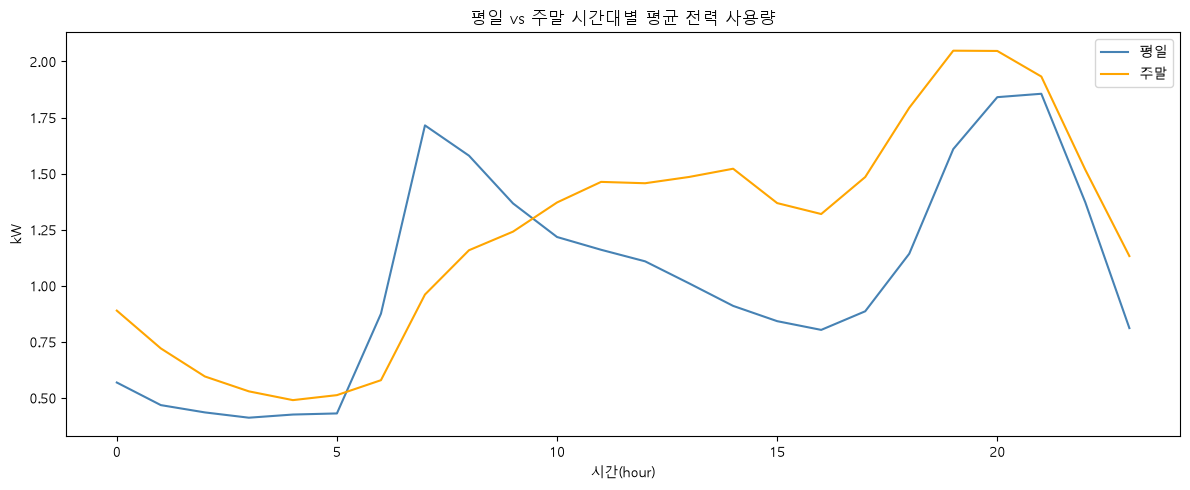

In [28]:
# 평일 vs 주말 비교 (변동성이 다른지 확인 - 나중에 이상치 기준을 요일별로 다르게 잡을 근거)
df["is_weekend"] = df["dayofweek"].isin([5, 6])

weekday_hourly = df[~df["is_weekend"]].groupby("hour")["Global_active_power"].agg(["mean", "std"])
weekend_hourly = df[df["is_weekend"]].groupby("hour")["Global_active_power"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekday_hourly.index, weekday_hourly["mean"], label="평일", color="steelblue")
ax.plot(weekend_hourly.index, weekend_hourly["mean"], label="주말", color="orange")
ax.set_title("평일 vs 주말 시간대별 평균 전력 사용량")
ax.set_xlabel("시간(hour)")
ax.set_ylabel("kW")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# 변동계수(CV = std/mean)로 "어느 시간대가 가장 예측하기 어려운(변동이 큰) 시간대인지" 확인
hourly_stats["cv"] = hourly_stats["std"] / hourly_stats["mean"]
print(hourly_stats.sort_values("cv", ascending=False))

          mean       std    min     max        cv
hour                                             
6     0.791631  0.928929  0.078   8.310  1.173437
0     0.659434  0.717914  0.078   7.698  1.088682
1     0.539325  0.585604  0.078  10.290  1.085809
2     0.480618  0.488526  0.078   6.248  1.016455
15    0.990815  1.002492  0.078   8.848  1.011785
16    0.948942  0.955823  0.078   8.446  1.007251
17    1.055100  1.037659  0.078  11.122  0.983470
5     0.453674  0.445886  0.078   6.376  0.982834
23    0.902142  0.881516  0.078   8.746  0.977137
3     0.444866  0.430038  0.078   4.426  0.966669
4     0.443847  0.425120  0.078   4.796  0.957807
14    1.082881  1.029232  0.078   8.418  0.950457
13    1.144538  1.048987  0.078   9.590  0.916516
18    1.326465  1.204779  0.078   9.724  0.908262
12    1.207076  1.067104  0.078   9.224  0.884040
11    1.245797  1.004152  0.078   8.504  0.806032
19    1.733347  1.350010  0.076  10.670  0.778846
22    1.412674  1.096782  0.078   9.272  0.776387


In [30]:
# IQR 기반 극단값 탐지
Q1 = df["Global_active_power"].quantile(0.25)
Q3 = df["Global_active_power"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Global_active_power"] < lower_bound) | (df["Global_active_power"] > upper_bound)]
print(f"IQR 기준 극단값 개수: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"정상 범위: {lower_bound:.2f} ~ {upper_bound:.2f} kW")

IQR 기준 극단값 개수: 94919 (4.57%)
정상 범위: -1.52 ~ 3.36 kW


hour
0      1147
1       593
2       239
3        82
4        80
5       103
6      2339
7      4556
8      4651
9      4047
10     3505
11     4494
12     4769
13     4436
14     4344
15     3648
16     2928
17     3529
18     5935
19    10263
20    11568
21    10304
22     5271
23     2088
Name: count, dtype: int64


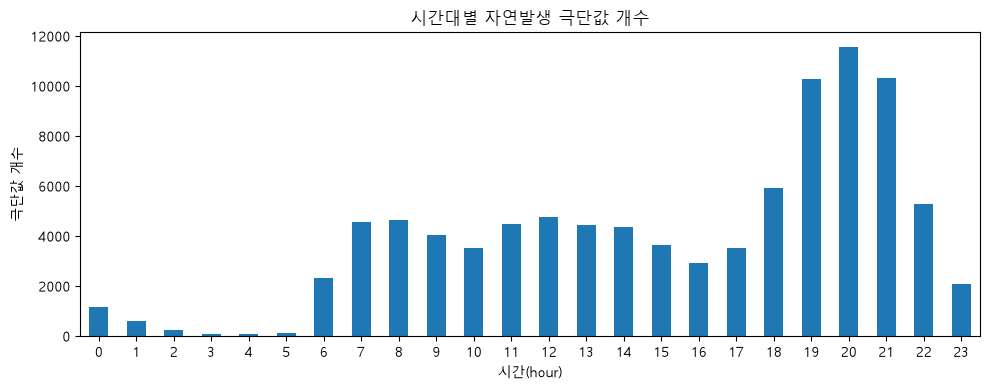

In [36]:
# 극단값들이 특정 시간대/날짜에 몰려있는지 확인
outlier_by_hour = outliers["hour"].value_counts().sort_index()
print(outlier_by_hour)

fig, ax = plt.subplots(figsize=(10, 4))
outlier_by_hour.plot(kind="bar", ax=ax)
# x축 글씨 가로로 표시
ax.tick_params(axis='x', rotation=0)
ax.set_title("시간대별 자연발생 극단값 개수")
ax.set_xlabel("시간(hour)")
ax.set_ylabel("극단값 개수")
plt.tight_layout()
plt.show()

In [32]:
# 극단값 중 가장 튀는 사례 top 10 확인 (실제로 어떤 상황인지 살펴보기)
top_outliers = df.reindex(
    df["Global_active_power"].sub((lower_bound+upper_bound)/2).abs().sort_values(ascending=False).index
).head(10)
print(top_outliers[["datetime", "Global_active_power", "hour", "dayofweek"]])

                   datetime  Global_active_power  hour  dayofweek
1150545 2009-02-22 17:09:00               11.122    17          6
112450  2007-03-04 19:34:00               10.670    19          6
112449  2007-03-04 19:33:00               10.650    19          6
1150544 2009-02-22 17:08:00               10.536    17          6
1029775 2008-11-30 20:19:00               10.348    20          6
968160  2008-10-19 01:24:00               10.290     1          6
586200  2008-01-27 19:24:00               10.162    19          6
112448  2007-03-04 19:32:00               10.154    19          6
1029773 2008-11-30 20:17:00               10.074    20          6
968161  2008-10-19 01:25:00               10.064     1          6


In [33]:
# Sub_metering 합계 vs Global_active_power 비교 (단위 환산: kW -> Wh/min 고려)
# Global_active_power(kW)를 분당 Wh로 환산: kW * 1000 / 60
df["global_active_power_wh"] = df["Global_active_power"] * 1000 / 60
df["submetering_sum"] = df["Sub_metering_1"] + df["Sub_metering_2"] + df["Sub_metering_3"]

# 나머지 미측정 가전 사용량 (이론상 항상 양수여야 정상)
df["unmetered"] = df["global_active_power_wh"] - df["submetering_sum"]

print(df["unmetered"].describe())

count    2.049356e+06
mean     9.315005e+00
std      9.586211e+00
min     -2.400000e+00
25%      3.800000e+00
50%      5.500000e+00
75%      1.036667e+01
max      1.248333e+02
Name: unmetered, dtype: float64


In [34]:
# unmetered가 음수인 경우 확인 (이론적으로 불가능 -> 계측 오류 or 설비 이상 의심)
negative_unmetered = df[df["unmetered"] < 0]
print(f"unmetered 음수 케이스 개수: {len(negative_unmetered)} ({len(negative_unmetered)/len(df)*100:.3f}%)")
negative_unmetered[["datetime", "Global_active_power", "submetering_sum", "unmetered"]].head(10)

unmetered 음수 케이스 개수: 1050 (0.051%)


,datetime,Global_active_power,submetering_sum,unmetered
176580,2007-04-18 08:24:00,2.992,50.0,-0.133333
176582,2007-04-18 08:26:00,1.554,27.0,-1.100000
183814,2007-04-23 08:58:00,2.014,34.0,-0.433333
200571,2007-05-05 00:15:00,0.338,6.0,-0.366667
202931,2007-05-06 15:35:00,0.828,14.0,-0.200000
267276,2007-06-20 08:00:00,1.194,20.0,-0.100000
267280,2007-06-20 08:04:00,1.302,22.0,-0.300000
267343,2007-06-20 09:07:00,2.546,43.0,-0.566667
277326,2007-06-27 07:30:00,3.110,52.0,-0.166667
277761,2007-06-27 14:45:00,0.268,5.0,-0.533333


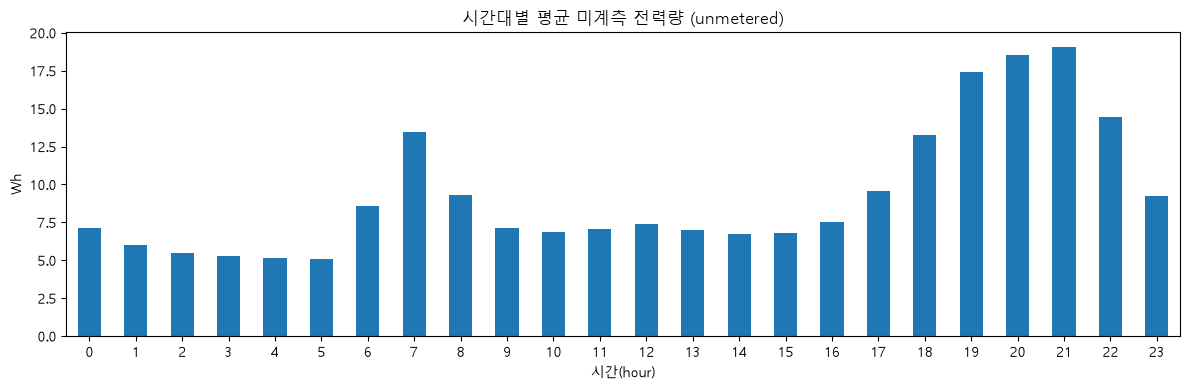

In [37]:
# unmetered 값의 시간대별 분포 (특정 시간대에 이상하게 몰리는지)
fig, ax = plt.subplots(figsize=(12, 4))
df.groupby("hour")["unmetered"].mean().plot(kind="bar", ax=ax)
# x축 글씨 가로로 표시
ax.tick_params(axis='x', rotation=0)
ax.set_title("시간대별 평균 미계측 전력량 (unmetered)")
ax.set_xlabel("시간(hour)")
ax.set_ylabel("Wh")
plt.tight_layout()
plt.show()